In [53]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)


In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()


(100, 6)


,col1,col2,col3,col4,col5,target
0,1.266544,-0.980594,-2.021335,0.418500,0.172689,0
1,0.362598,-0.110694,-1.265795,0.550253,-0.836980,0
2,2.552741,0.714993,1.046201,0.528685,-1.644475,1
3,1.006039,-0.790372,-0.919594,0.572866,-0.979601,0
4,-0.134931,-1.154126,-0.703716,0.610274,0.324720,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)


In [54]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [39]:
df1 = sample_rows(df,0.2)

In [40]:
df2 = sample_rows(df,0.2)

In [41]:
df3 = sample_rows(df,0.2)

In [42]:
df1.shape

(20, 6)

In [43]:
from sklearn.tree import DecisionTreeClassifier
cl1 = DecisionTreeClassifier()
cl2 = DecisionTreeClassifier()
cl3 = DecisionTreeClassifier()

In [44]:
cl1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
cl2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
cl3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [45]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[1] <= -0.39\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.4, 0.5, 'x[3] <= 0.172\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.7, 0.6666666666666667, '  False')]

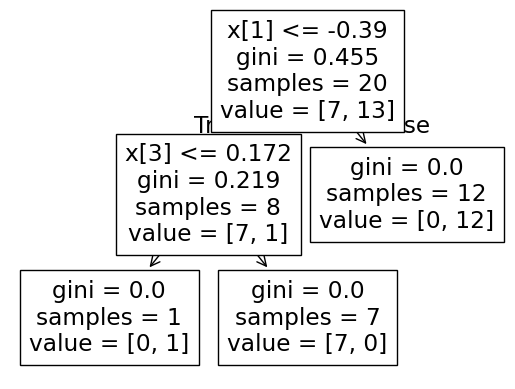

In [46]:
plot_tree(cl1)

[Text(0.6, 0.8333333333333334, 'x[1] <= -0.114\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[3] <= 0.179\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.7, 0.6666666666666667, '  False')]

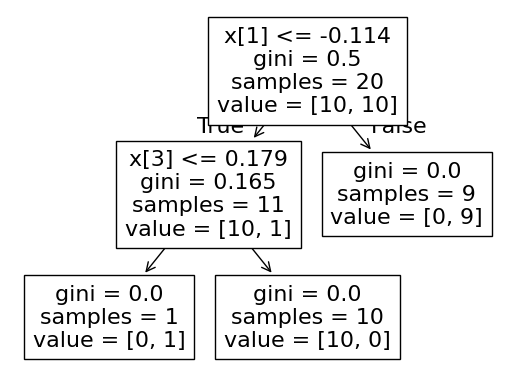

In [47]:
plot_tree(cl2)

[Text(0.5, 0.75, 'x[3] <= 0.485\ngini = 0.48\nsamples = 20\nvalue = [12, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.625, 0.5, '  False')]

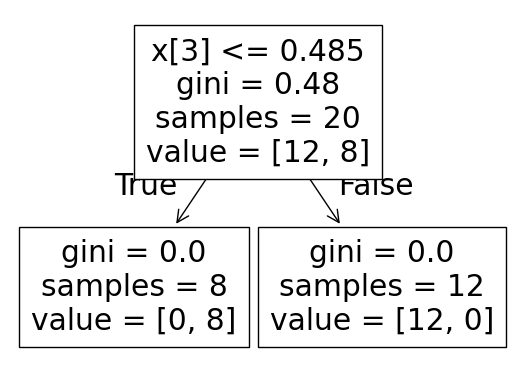

In [48]:
plot_tree(cl3)

In [49]:
cl1.predict(np.array([0.36259832986638096,-0.11069413194891642,-1.2657947448054374,0.550253094685647,-0.8369800966674867]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [50]:
cl2.predict(np.array([0.36259832986638096,-0.11069413194891642,-1.2657947448054374,0.550253094685647,-0.8369800966674867]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [51]:
cl3.predict(np.array([0.36259832986638096,-0.11069413194891642,-1.2657947448054374,0.550253094685647,-0.8369800966674867]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [67]:
df1 = sample_features(df,0.5)
df2 = sample_features(df,0.5)
df3 = sample_features(df,0.5)

/tmp/ipykernel_2197/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_2197/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_2197/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [68]:
from sklearn.tree import DecisionTreeClassifier
cl1 = DecisionTreeClassifier()
cl2 = DecisionTreeClassifier()
cl3 = DecisionTreeClassifier()

In [69]:
cl1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
cl2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
cl3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

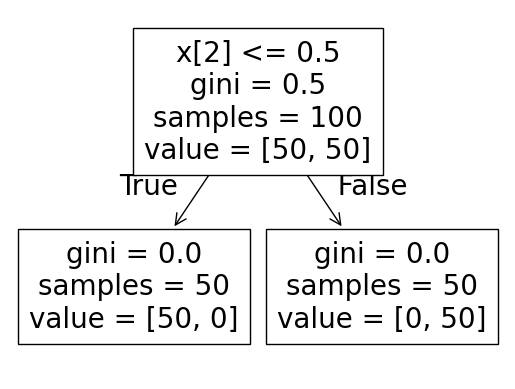

In [70]:
plot_tree(cl1)

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

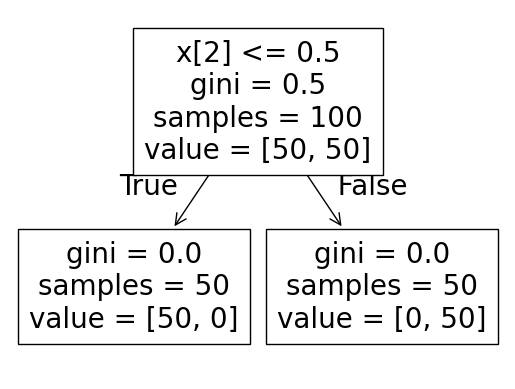

In [71]:
plot_tree(cl2)

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

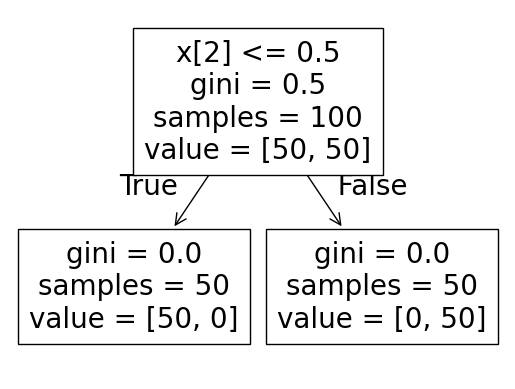

In [72]:
plot_tree(cl3)